In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\Users\inter\OneDrive\Desktop\sakshi\Machine Learning Project .ipynb\Heart Disease Project\heart_disease_health_indicators_BRFSS2015.csv')
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.shape

(253680, 22)

In [4]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [5]:
# The target column in this dataset is named 'HeartDiseaseorAttack'
df['HeartDiseaseorAttack'].unique()

array([0., 1.])

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
Diabetes,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

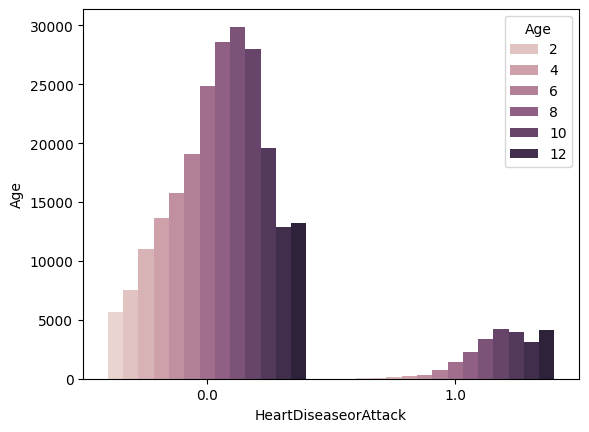

In [8]:
import matplotlib.pyplot as plt
sns.countplot(data=df, x='HeartDiseaseorAttack', hue='Age')
plt.xlabel('HeartDiseaseorAttack')
plt.ylabel('Age')
plt.show()

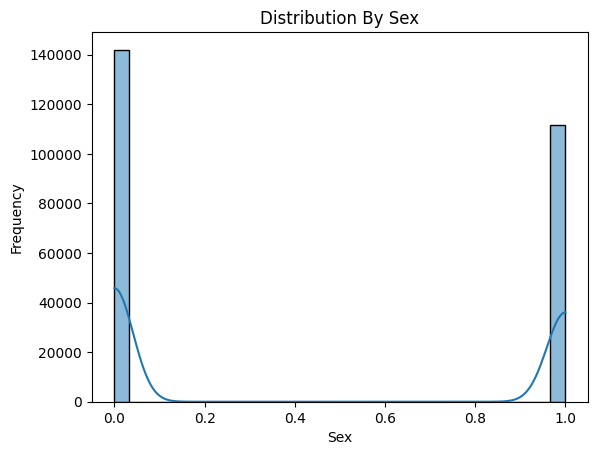

In [9]:
sns.histplot(df['Sex'], bins=30, kde=True)
plt.title('Distribution By Sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.show()

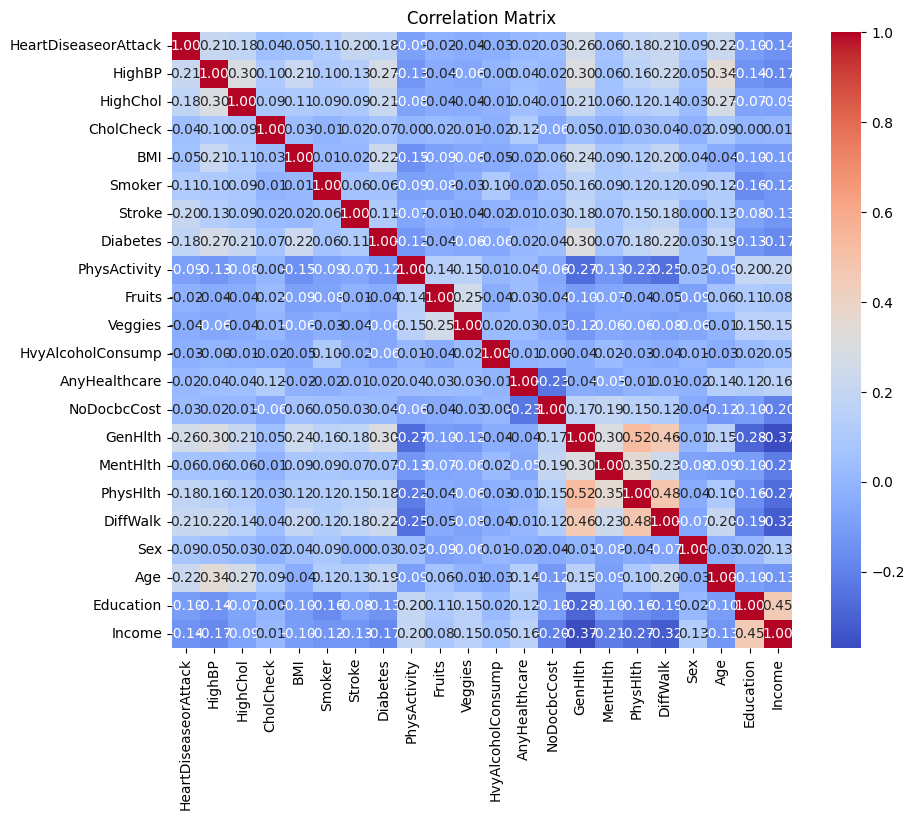

In [10]:
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

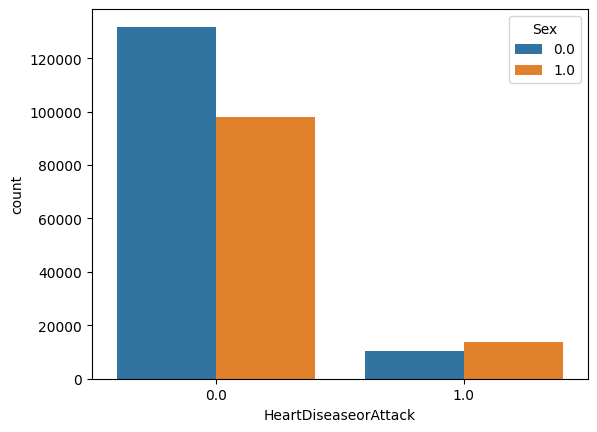

In [11]:
sns.countplot(data=df, x='HeartDiseaseorAttack', hue='Sex');
plt.show()

C:\Users\inter\AppData\Local\Temp\ipykernel_4952\1633810273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='HeartDiseaseorAttack', y='Age', data=df, palette='muted')


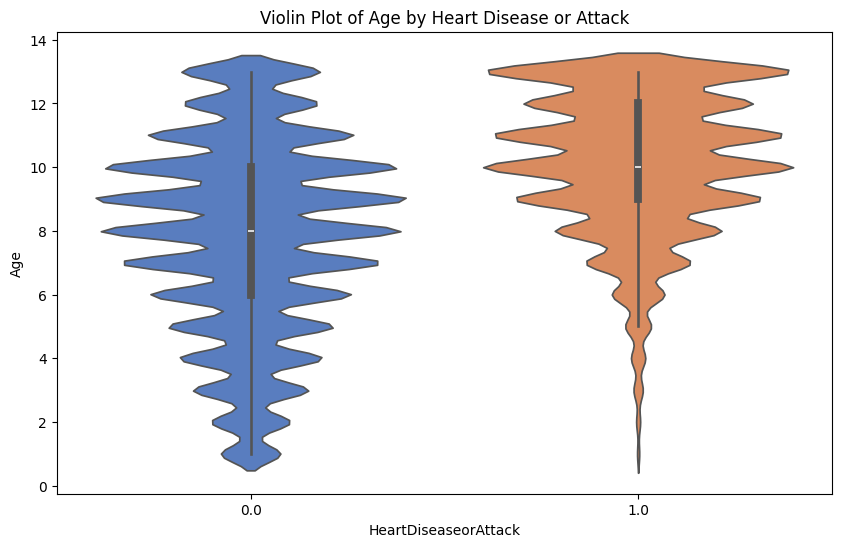

In [12]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='HeartDiseaseorAttack', y='Age', data=df, palette='muted')
plt.title('Violin Plot of Age by Heart Disease or Attack')
plt.xlabel('HeartDiseaseorAttack')
plt.ylabel('Age')
plt.show()

C:\Users\inter\AppData\Local\Temp\ipykernel_4952\1949166302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='HeartDiseaseorAttack', y='HighChol', data=df, palette='cool')


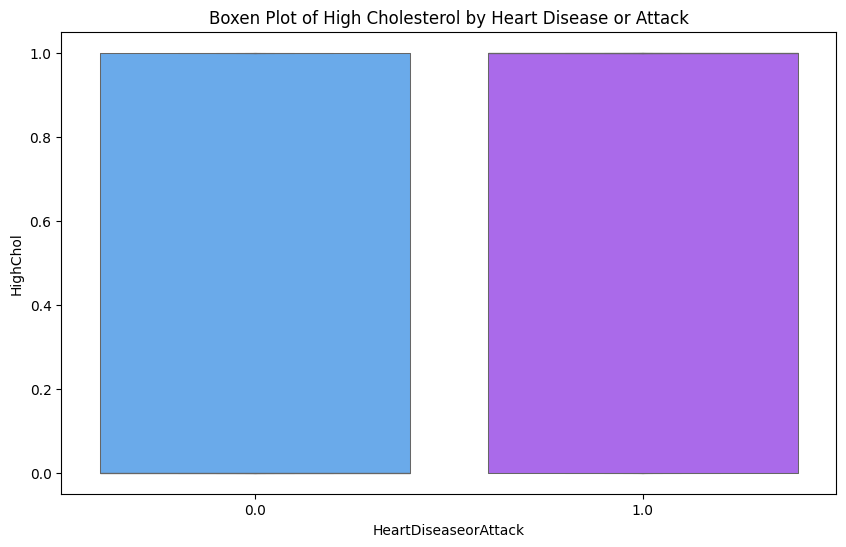

In [13]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x='HeartDiseaseorAttack', y='HighChol', data=df, palette='cool')
plt.title('Boxen Plot of High Cholesterol by Heart Disease or Attack')
plt.xlabel('HeartDiseaseorAttack')
plt.ylabel('HighChol')
plt.show()

In [14]:
import pickle 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Check for non-numeric entries in the dataset
df.replace('?', np.nan, inplace=True)  
df.dropna(inplace=True)
df=df.astype(float)

X=df.drop('HeartDiseaseorAttack',axis=1)
y=df['HeartDiseaseorAttack']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

with open('scaler.pkl','wb')as scaler_file:
    pickle.dump(scaler,scaler_file)


with open('scaler.pkl','rb')as scaler_file:
    scaler=pickle.load(scaler_file)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred_log_reg=log_reg.predict(X_test)
accuracy_log_reg=accuracy_score(y_test,y_pred_log_reg)
conf_matrix_log_reg=confusion_matrix(y_test,y_pred_log_reg)
class_report_log_reg=classification_report(y_test,y_pred_log_reg)
print(f"Logistic Regression Accuracy:{accuracy_log_reg:.2f}")
print('confusion_matrix:')
print(conf_matrix_log_reg)
print('classification_report:')
print(class_report_log_reg)

Logistic Regression Accuracy:0.91
confusion_matrix:
[[45462   506]
 [ 4138   630]]
classification_report:
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     45968
         1.0       0.55      0.13      0.21      4768

    accuracy                           0.91     50736
   macro avg       0.74      0.56      0.58     50736
weighted avg       0.88      0.91      0.88     50736



In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tree_clf=DecisionTreeClassifier()
tree_clf.fit(X_train,y_train)
y_pred_tree=tree_clf.predict(X_test)
accuracy_tree=accuracy_score(y_test,y_pred_tree)
conf_matrix_tree=confusion_matrix(y_test,y_pred_tree)
class_report_tree=classification_report(y_test,y_pred_tree)
print(f'Decision Tree Accuracy:{accuracy_tree:.2f}')
print('Confusion matrix:')
print(conf_matrix_tree)
print('classification_report')
print(class_report_tree)

Decision Tree Accuracy:0.85
Confusion matrix:
[[41805  4163]
 [ 3464  1304]]
classification_report
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92     45968
         1.0       0.24      0.27      0.25      4768

    accuracy                           0.85     50736
   macro avg       0.58      0.59      0.59     50736
weighted avg       0.86      0.85      0.85     50736



In [17]:
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_clf=KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train,y_train)
y_pred_knn=knn_clf.predict(X_test)
accuracy_knn=accuracy_score(y_test,y_pred_knn)
conf_matrix_knn=confusion_matrix(y_test,y_pred_knn)
class_report_knn=classification_report(y_test,y_pred_knn)
print(f'k-NN Accuracy:{accuracy_knn:.2f}')
print('Confusion matrix:')
print(conf_matrix_knn)
print('classification_report')
print(class_report_knn)

file_name='Heart_disease_model.pickle'
pickle.dump(knn_clf,open(file_name,'wb'))
loaded_model=pickle.load(open(file_name,'rb'))

k-NN Accuracy:0.90
Confusion matrix:
[[44725  1243]
 [ 4006   762]]
classification_report
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     45968
         1.0       0.38      0.16      0.23      4768

    accuracy                           0.90     50736
   macro avg       0.65      0.57      0.58     50736
weighted avg       0.87      0.90      0.88     50736



In [ ]:
from sklearn import svm

clf = svm.SVC(decision_function_shape='ovo')
clf.fit(X_test,y_test)
y_pred_clf=clf.predict(X_test)
accuracy_clf=accuracy_score(y_test,y_pred_clf)
conf_matrix_clf=confusion_matrix(y_test,y_pred_clf) 
class_report_clf=classification_report(y_test,y_pred_clf)
print(f'SVM:{accuracy_clf:.2f}')
print('Confusion matrix:')
print(conf_matrix_clf)
print('classification_report')
print(class_report_clf)

In [ ]:
from sklearn.linear_model import SGDClassifier
classify=SGDClassifier(loss='hinge',penalty='l2',max_iter=5)
classify.fit(X_test,y_test)
y_pred_classify=classify.predict(X_test)
accuracy_classify=accuracy_score(y_test,y_pred_classify)
conf_matrix_classify=confusion_matrix(y_test,y_pred_classify) 
class_report_classify=classification_report(y_test,y_pred_classify)
print(f'SGD:{accuracy_classify:.2f}')
print('Confusion matrix:')
print(conf_matrix_classify)
print('classification_report')
print(class_report_classify)

SGD:0.90
Confusion matrix:
[[45373   595]
 [ 4287   481]]
classification_report
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45968
         1.0       0.45      0.10      0.16      4768

    accuracy                           0.90     50736
   macro avg       0.68      0.54      0.56     50736
weighted avg       0.87      0.90      0.88     50736



c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


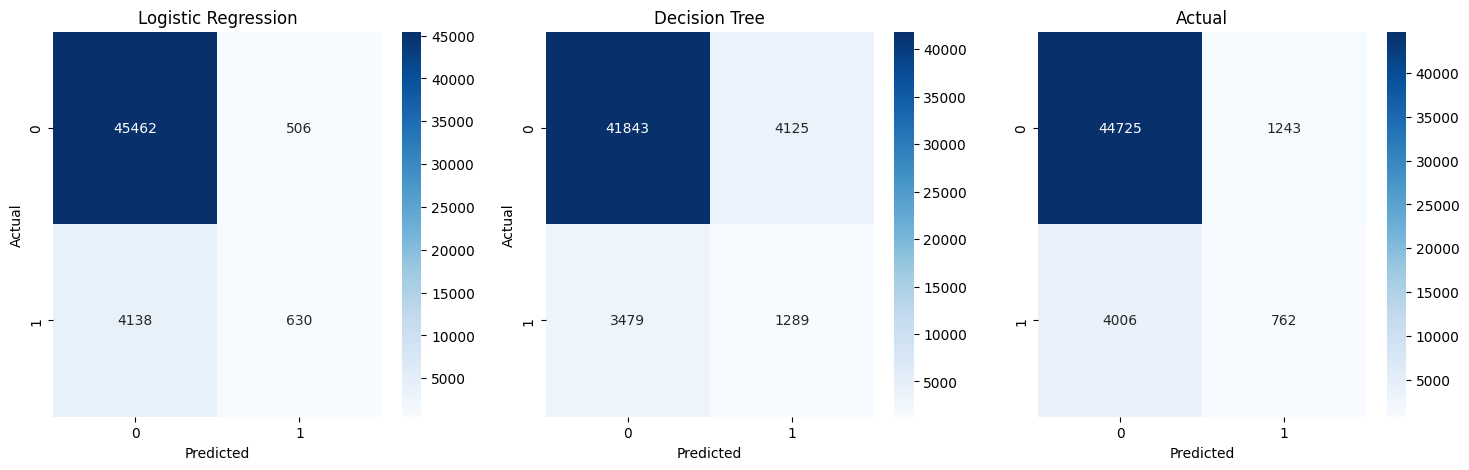

In [ ]:
#visualizing 
fig,axes=plt.subplots(1,3,figsize=(18,5))
#logistic regression
sns.heatmap(conf_matrix_log_reg,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#Decision Tree
sns.heatmap(conf_matrix_tree,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

#knn
sns.heatmap(conf_matrix_knn,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_title('Actual')
plt.show()

In [1]:
import pickle
import numpy as np

def infer_heart_disease(model_path, scaler_path, input_features):
    """
    Perform inferencing on the heart disease dataset.

    Parameters:
    - model_path (str): Path to the saved model pickle file.
    - scaler_path (str): Path to the saved scaler pickle file.
    - input_features (list): List of input features in the order:
      [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]

    Returns:
    - str: "Disease Detected" if target is 1, otherwise "No Disease".
    """
    try:
        # Load the trained model and scaler
        with open(r'C:\Users\Admin\Desktop\DATA SCIENCE ND AI\Machine Learning\Heart Disease Project\Heart_disease_model.pickle', 'rb') as model_file:
            model = pickle.load(model_file)

        with open(r'C:\Users\Admin\Desktop\DATA SCIENCE ND AI\Machine Learning\Heart Disease Project\scaler.pkl', 'rb') as scaler_file:
            scaler = pickle.load(scaler_file)

        # Ensure the input features are in the correct format
        input_array = np.array([input_features]).reshape(1, -1)

        # Scale the input features
        scaled_input = scaler.transform(input_array)

        # Predict outcome
        prediction = model.predict(scaled_input)

        # Return result
        return "Disease Detected" if prediction[0] == 1 else "No Disease"

    except Exception as e:
        return f"An error occurred: {e}"

In [ ]:
# Example input: Replace with actual feature values
input_features = [45, 1, 3, 120, 233, 0, 1, 150, 0, 2.3, 0, 0, 1]

# Paths to your saved model and scaler
model_path = 'heart_disease_model.pkl'(r'C:\Users\Admin\Desktop\DATA SCIENCE ND AI\Machine Learning\Heart Disease Project\Heart_disease_model.pickle', 'rb') 
scaler_path = 'scaler.pkl'

# Perform inference
result = infer_heart_disease(model_path, scaler_path, input_features)
print(result)

NameError: name 'model_path' is not defined